In [1]:
import sys
sys.executable

'd:\\Deep Learning\\Perceptron\\my_env\\Scripts\\python.exe'

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import requests

In [3]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,
                        hypercube=False,class_sep=10)

<Axes: >

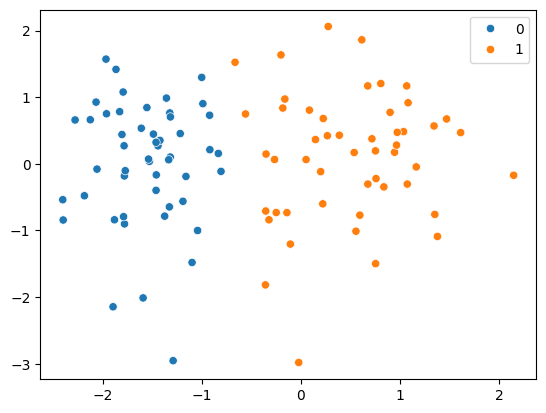

In [4]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [5]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [6]:
np.insert(X,0,1,axis=1)

array([[ 1.        ,  0.19924745, -0.11697552],
       [ 1.        , -0.24882029, -0.73115232],
       [ 1.        , -0.3544904 , -0.7081059 ],
       [ 1.        , -1.59086506, -2.01199214],
       [ 1.        , -0.20083951,  1.63493163],
       [ 1.        , -0.83241122,  0.15599044],
       [ 1.        , -1.79207014,  1.07782053],
       [ 1.        ,  0.0856607 ,  0.80626713],
       [ 1.        , -0.55865299,  0.74859527],
       [ 1.        , -1.95974262,  0.75152794],
       [ 1.        , -1.77828947, -0.90114581],
       [ 1.        , -1.77985853, -0.1815243 ],
       [ 1.        , -0.02194151, -2.98092432],
       [ 1.        ,  0.80563431,  1.20500136],
       [ 1.        , -1.82701214,  0.78302407],
       [ 1.        ,  0.38730728,  0.42968688],
       [ 1.        , -0.14108668, -0.73229726],
       [ 1.        , -1.87955941, -0.83930476],
       [ 1.        , -0.18232911,  0.83727062],
       [ 1.        , -1.77059533, -0.10255323],
       [ 1.        , -2.27658028,  0.658

In [7]:
X.shape

(100, 2)

In [11]:
X.shape[0]

100

In [10]:
X.shape[1]

2

In [9]:
np.ones(X.shape[1])

array([1., 1.])

In [12]:
def step(z):
    return 1 if z>0 else 0

In [13]:
def perceptron(X,y):
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,X.shape[0])
        y_hat=step(np.dot(X[j],weights))
        weights=weights+lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [14]:
intercept_,coef_=perceptron(X,y)

In [17]:
print("Intercept (Bias) :",intercept_ )
print("Coffecient (Weights):",coef_)

Intercept (Bias) : 1.0
Coffecient (Weights): [1.32853822 0.04735331]


In [18]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [19]:
print(m)
print(b)

-28.055867325780007
-21.117847323111285


In [20]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

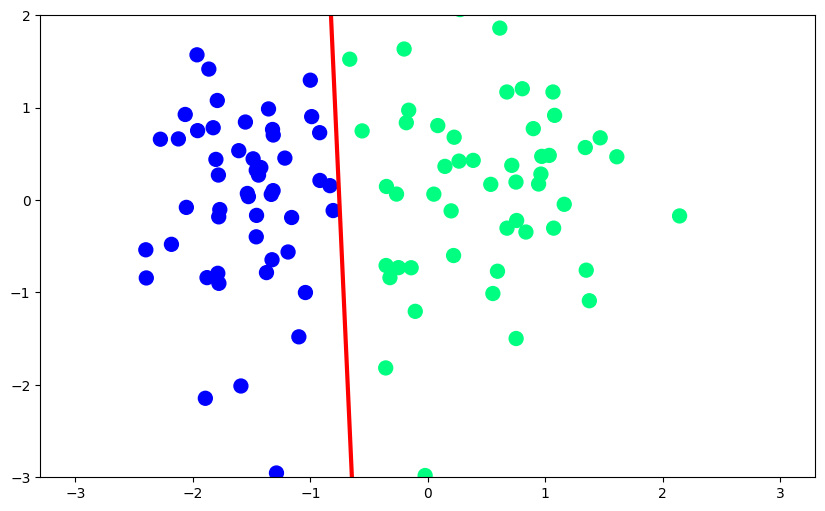

In [21]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [28]:
from IPython.display import HTML
import matplotlib.animation as animation
history = []
X_anim = np.insert(X, 0, 1, axis=1)
weights = np.ones(X_anim.shape[1])

for i in range(1000):
    j = np.random.randint(0, X_anim.shape[0])
    y_hat = step(np.dot(X_anim[j], weights))
    weights = weights + 0.1 * (y[j] - y_hat) * X_anim[j]
    if i % 20 == 0:
        history.append(weights.copy())

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
x_input = np.linspace(-3, 3, 100)
line, = ax.plot([], [], color='red', linewidth=3)
ax.set_ylim(-3, 2)

def update(frame):
    w = history[frame]
    line.set_data(x_input, -(w[1] * x_input + w[0]) / w[2])
    ax.set_title(f'Step {frame * 20}')
    return line,

ani = animation.FuncAnimation(fig, update, frames=len(history), interval=100)
plt.close()
HTML(ani.to_jshtml())  

By Library Implementation

In [29]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,
                        hypercube=False,class_sep=10)

In [30]:
from sklearn.linear_model import Perceptron
p=Perceptron()
p.fit(X,y)
print(p.intercept_)
print(p.coef_)

[3.]
[[4.30310075 0.18860799]]


<Axes: >

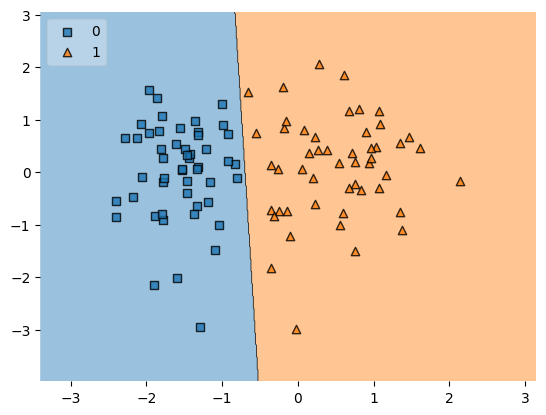

In [32]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y,clf=p,legend=2)